# Phase 1 RERUN — Stage A: re-derive the age axis within batch

**Context.** The prior run (`FINDINGS.md`) halted at STOP 1b: under `expression ~ cell_type + age`, OneK1K's A-genes were
depth-artifact genes, because donors were not age-randomised across the 75 multiplexed 10x pools and per-cell depth is a pool
property (R² = 0.86). This rerun discards the prior A-gene set and re-derives Phase 1 from 1a under the corrected model

`expression ~ C(cell_type) + C(pool) + log(mean UMI/cell) + log(mean genes/cell) + age`

Reused from the prior run: cached raw data (`data/raw/`), the pseudobulk construction (`src/pseudobulk.py`,
`src/run_pseudobulk_onek1k.py`), the log-CPM normalisation (`decomp.normalize_logcpm`) and the confound gene lists / flags
(`src/gene_lists.py`, `src/confounds.py`). Thresholds (`decomp.PRIMARY_THRESH`, `decomp.SWEEP`) are **unchanged**.
All outputs are namespaced: `results/rerun/`, `results/tables/rerun_*.csv`, `results/figures/rerun_*.png`.

**Outcome of this notebook: STOP CONDITION A fired (2 A-genes survive; stop line = 10). Stages B–D were not run.**
See `FINDINGS_RERUN.md`.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, os.path.join(ROOT, "src"))
os.environ["PYTHONUTF8"] = "1"
from config import *
from rerun_common import RERUN_DIR, RERUN_SEED
import subprocess
def sh(*args):
    """run a src/ script in a subprocess and embed its stdout in the notebook"""
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(r.stdout)
    if r.returncode:
        print(r.stderr); raise RuntimeError(f"{args[0]} exited with {r.returncode}")
print("ROOT:", ROOT, "| RERUN_SEED:", RERUN_SEED)

ROOT: <repo> | RERUN_SEED: 20260914


## Input (reused): pseudobulk and log-CPM
From a clean checkout, `rerun_common.ensure_logcpm()` (called inside `rerun_stageA.py`) rebuilds the pseudobulk from the cached OneK1K
h5ad via `src/run_pseudobulk_onek1k.py` and regenerates the log-CPM matrix with the same normalisation as the prior run. Filter log
(unchanged): `results/tables/onek1k_filter_log.csv`.

In [2]:
sh("src/run_pseudobulk_onek1k.py")
import pandas as pd
pd.read_csv(TAB / "onek1k_filter_log.csv")

[cached] <repo>\data\processed\onek1k_pseudobulk.h5ad exists; skipping build



,step,unit,before,after,removed,note
0,cells with numeric donor age,cells,1248980,1248980,0,non-numeric development_stage dropped
1,cells whose cell type is in the analysis map,cells,1248980,1243859,5121,"dropped raw labels: ['CD4 Proliferating', 'CD8..."
2,pseudobulk groups with >= 20 cells,groups,19754,9681,10073,NaN
3,cells in retained pseudobulk groups,cells,1243859,1170622,73237,NaN
4,cell types present in >= 100 donors,cell types,21,16,5,"dropped: {'NK_CD56bright': np.int64(33), 'Plas..."
5,cells in retained cell types,cells,1170622,1168986,1636,NaN


## A1–A4 and STOP A
`src/rerun_stageA.py` does, in order:

* **A0** design audit: donors nest in pools (asserted), `age ~ C(pool)` R², depth ~ pool R².
* **A1** per-gene commonality partition under the corrected model. Nuisance N = pool + within-type-centred log depth.
  `unique_age = R²(N+ct+age) − R²(N+ct)` is the **within-pool, depth-adjusted** age variance. The prior pooled model
  (`ct + age`) and a pool-only model (`ct + pool + age`) are computed alongside for comparison. Because the pseudobulks of one
  donor share its age, the nominal F test is anti-conservative; the primary inference is a **within-pool, donor-level permutation
  null** (1,000 draws, seed 20260914): empirical FDR per threshold, per-gene q-values, and a family-wise threshold on the maximum.
* **A2** A / I / MIXED sets with the unchanged primary thresholds and the unchanged sweep grid; comparison with the prior sets.
* **A3** known positives CDKN2A (p16, expected up) and LRRN3 (expected down): rank, slope sign, class, per-cell-type within-pool r.
* **A4** the prior run's confound filters (same lists, same fixed thresholds) applied to the new A set; survival at the primary
  thresholds and across the sweep.
* **STOP A** verdict → `results/rerun/stageA_STOP_verdict.txt`.

In [3]:
sh("src/rerun_stageA.py")

RERUN STAGE A — age axis within batch.  seed = 20260914 | N_PERM = 1000
[data] log-CPM pseudobulks: 9,623 x 13,904 genes | donors=981 | pools=75 | cell types=16 | every donor in exactly one pool: True

[A0] donors=981, pools=75 (donors/pool: min 9, median 13, max 14)
[A0] age ~ C(pool): R2=0.234, adj R2=0.172, p=3.81e-21  -> within-pool age variance available to the model = 76.6% of total donor age variance
[A0] R2( log mean UMI/cell [within-type-centred] ~ C(pool) ) = 0.855
[A0] R2( log mean genes/cell [within-type-centred] ~ C(pool) ) = 0.812
[A0] corrected model columns: 16 cell types + 74 pool contrasts + 2 depth + 1 age = 93 parameters on 9,623 pseudobulks

[A1] per-gene variance partition, corrected model

Corrected model — distribution over 13904 genes (fraction of total variance):
             0.500  0.900  0.950  0.990  0.999  1.000
unique_ct   0.1248 0.5062 0.6599 0.8336 0.9103 0.9610
unique_age  0.0001 0.0007 0.0010 0.0019 0.0046 0.0126
shared      0.0000 0.0011 0.0018 0.003

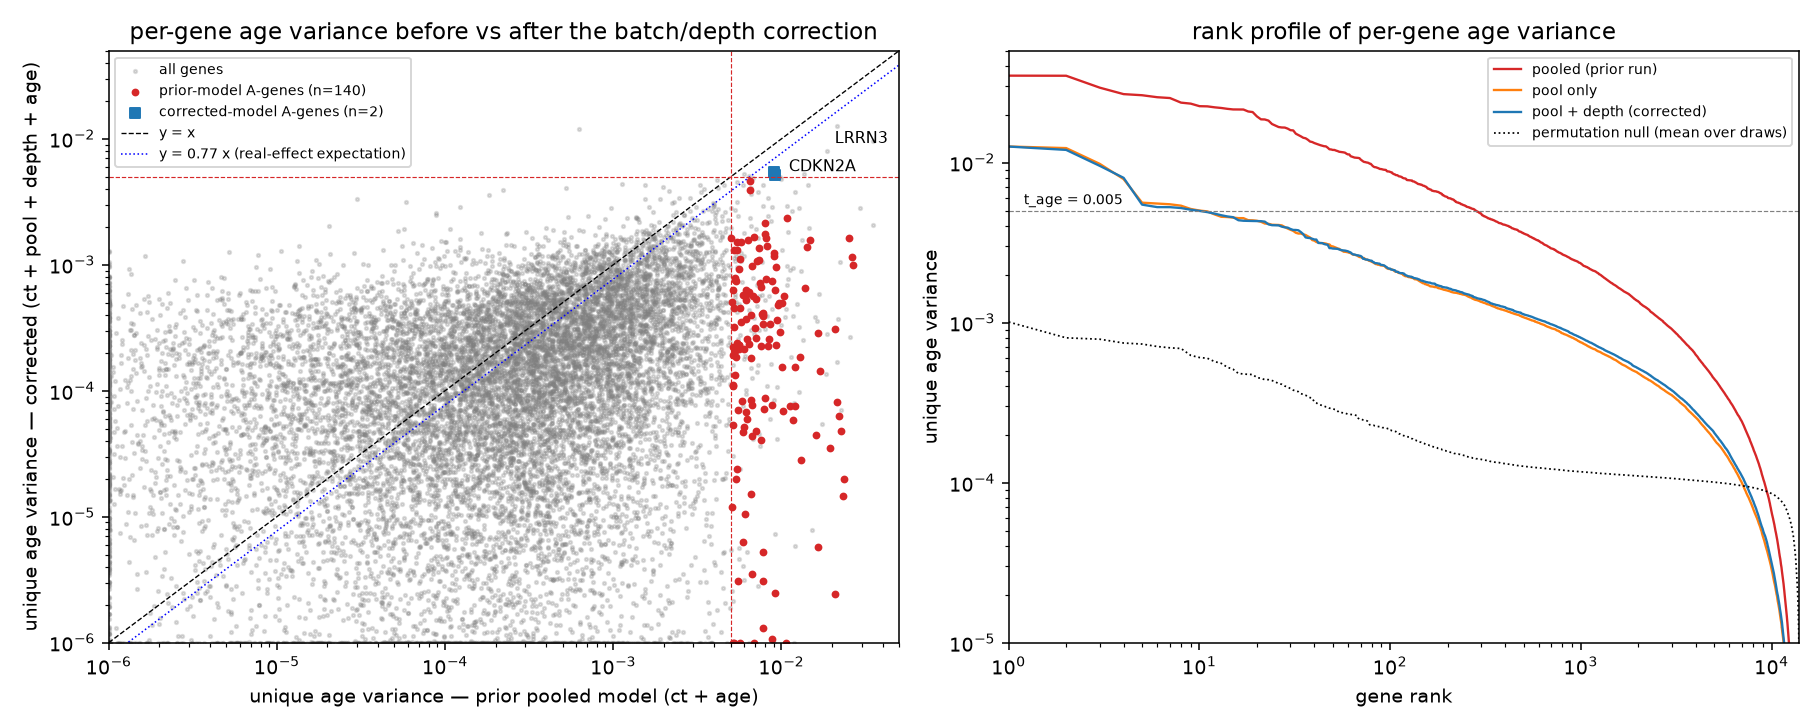

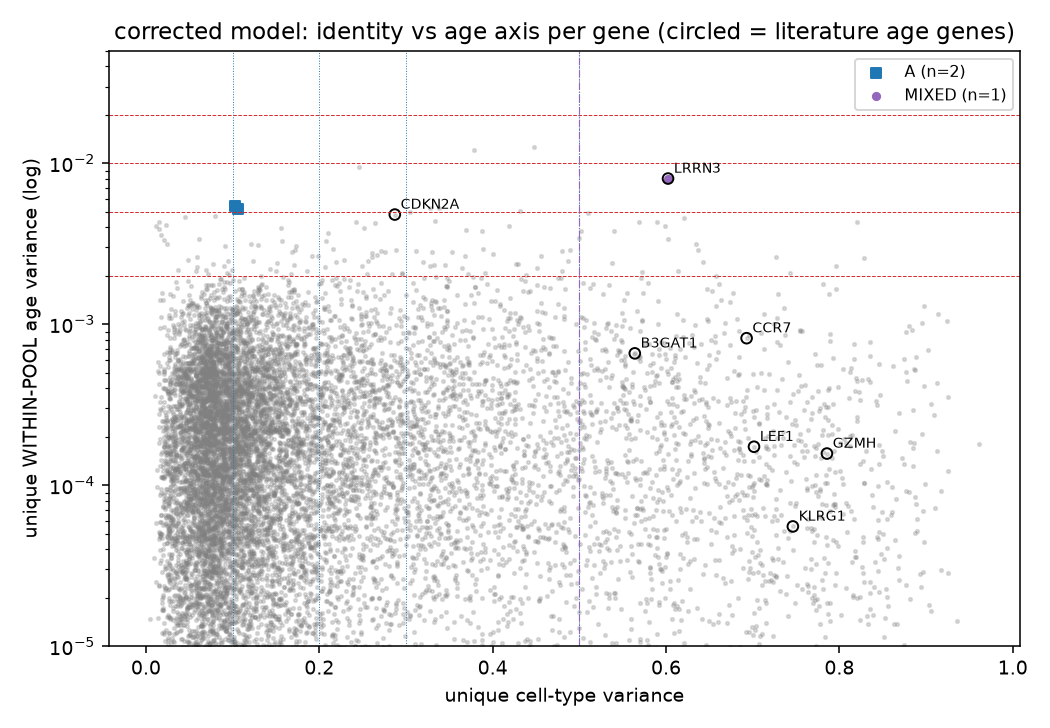

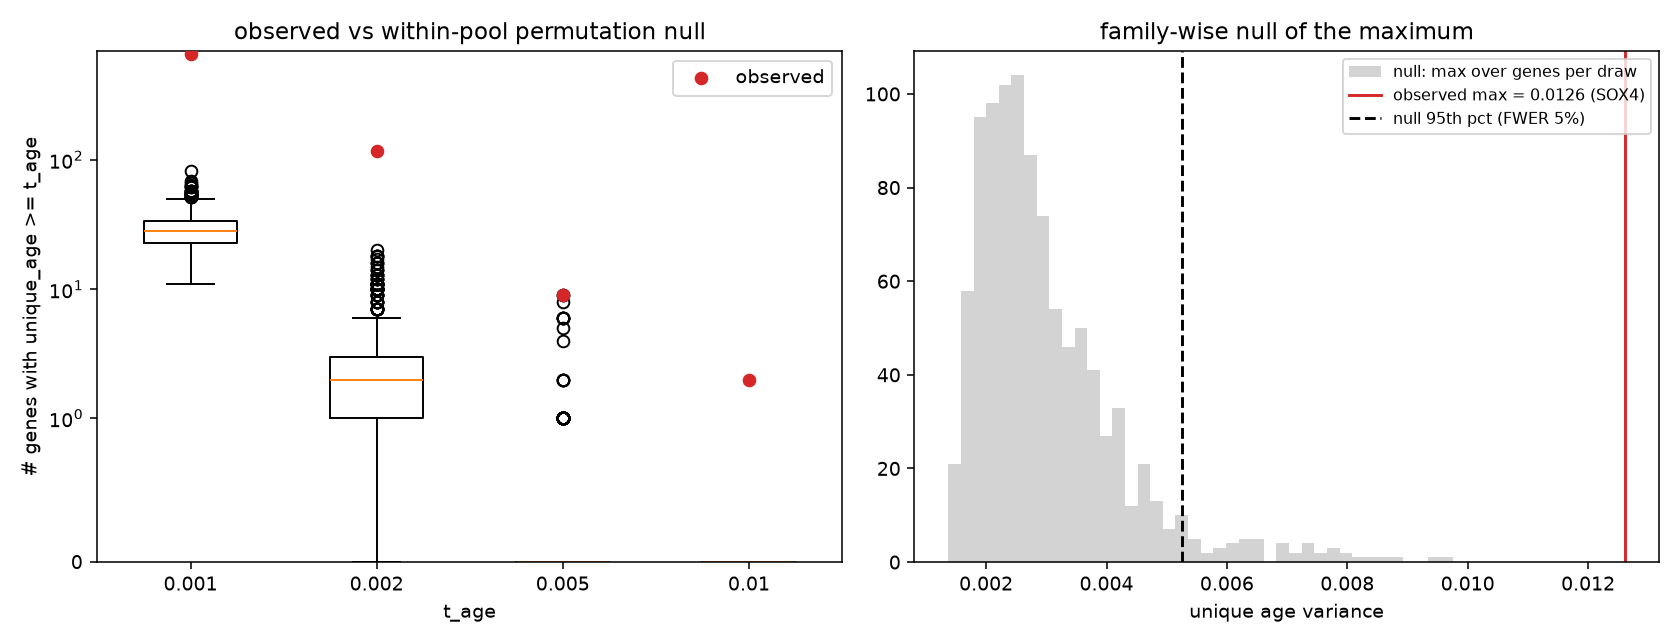

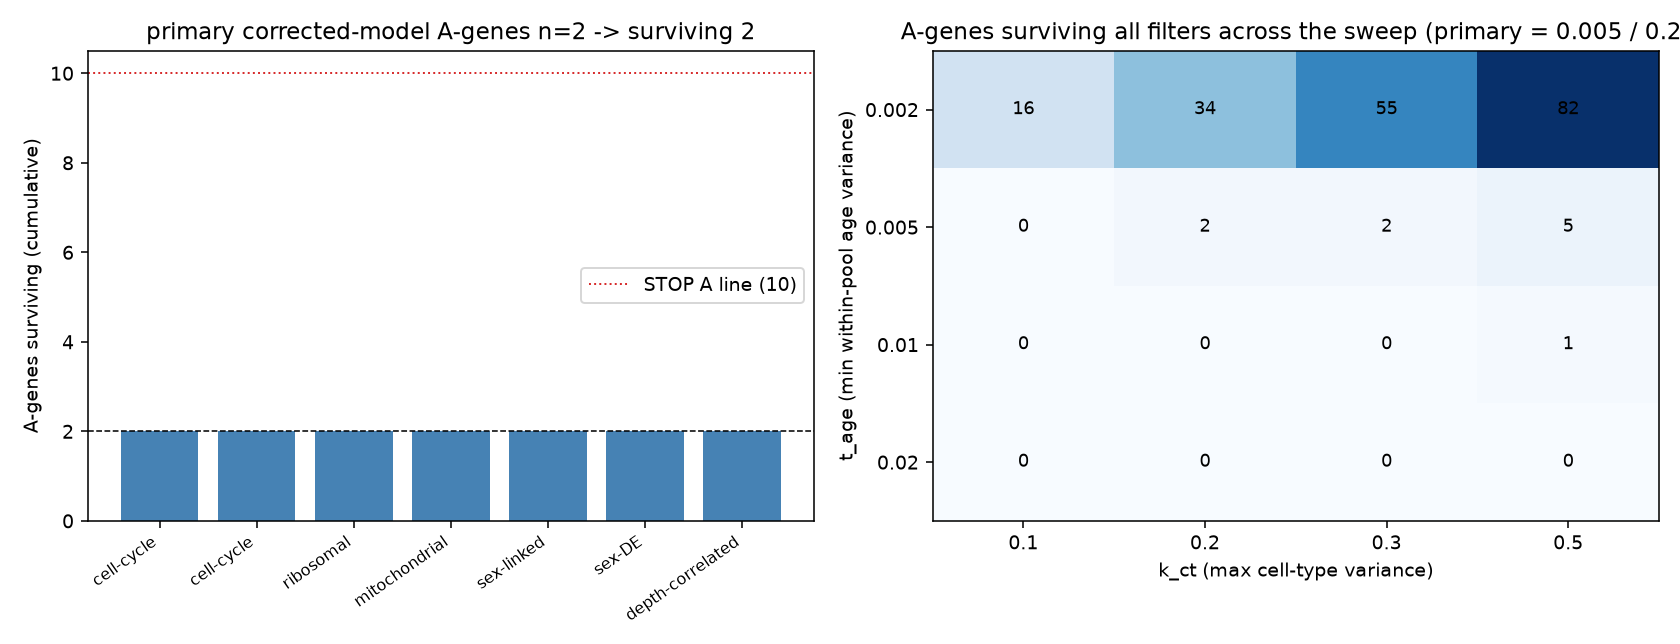

In [4]:
from IPython.display import Image, display
for f in ("rerun_stageA_pooled_vs_corrected_unique_age.png", "rerun_stageA_joint_variance_distribution.png",
          "rerun_stageA_permutation_null.png", "rerun_stageA_Agene_survival.png"):
    display(Image(str(FIG / f)))

## Verdict
STOP CONDITION A: **fewer than 10 A-genes survive** → the rerun halts here. Thresholds were not relaxed; Stages B, C, D were not run.
The cell below re-reads the verdict written by the script and asserts it, so a re-execution that changes the outcome fails loudly.

In [5]:
import json
s = json.load(open(RERUN_DIR / "stageA_summary.json"))
print(open(RERUN_DIR / "stageA_STOP_verdict.txt", encoding="utf-8").read())
assert s["fired"], "STOP A verdict changed on re-execution — FINDINGS_RERUN.md must be revisited"
print("\nRerun halted at STOP A. Stages B-D not executed.")

STOP CONDITION A — VERDICT  (primary thresholds {'t_age': 0.005, 'k_ct': 0.2, 't_ct': 0.5, 'k_age': 0.001}; filters = prior run's, unchanged)
corrected-model A-genes at primary thresholds: 2
A-genes surviving all confound filters:       2   (STOP A fires if < 10)
of these with within-pool permutation q<0.05:  2
genes with unique_age >= t_age=0.005 regardless of cell-type variance: 9 (permutation null mean 0.12)
genes with ANY within-pool age association (permutation BH q<0.05): 1180
known positives: CDKN2A slope +0.0084/yr (expected +), rank 12.0, unique_ct 0.287, class OTHER; LRRN3 slope -0.0119/yr (expected -), rank 4.0, unique_ct 0.602, class MIXED

VERDICT: STOP CONDITION A FIRED.
  Fewer than 10 A-genes survive. Under the corrected within-pool model the within-cell-type transcriptomic age signal in PBMC is
  too sparse to build a gene-set-restricted age score from at the pre-registered thresholds. Per the operating mode the rerun halts
  here: Stages B, C and D are NOT run. Thresh